In [1]:
import pandas as pd
import numpy as np

OBJECTIVE_NAMES = ['Utilitarian', 'Quadratic', 'Proportional Fairness', 'Harmonic Fairness',
                   'Max-Min', 'Convex_Comb (RMD)',
                   'Convex_Comb (Gini)', 'Convex_Comb (Jain)',
                   'Convex_Comb (Envy)', 'Egalitarian\n(No Charging)']


df_mip = pd.read_csv('output_mip.csv')
df_mip.insert(1, 'Group', (df_mip['Instance_Number']-1) // 10 + 1)
df_mip.sort_values(by=['Group', 'Instance_Number'], inplace=True)
df_mip['Objective_Index'] = df_mip['Objective_Index'].apply(lambda x: int(x)).astype(int)


df_h_lns_mip = pd.read_csv('output_h_lns_mip.csv')
df_h_lns_mip.insert(1, 'Group', (df_h_lns_mip['Instance_Number']-1) // 10 + 1)
df_h_lns_mip.sort_values(by=['Group', 'Instance_Number'], inplace=True)
df_h_lns_mip['Objective_Index'] = df_h_lns_mip['Objective_Index'].apply(lambda x: int(x)).astype(int)


df_h_lns = pd.read_csv('output_h_lns.csv')
df_h_lns['Objective_Index'] = df_h_lns['Objective_Index'].apply(lambda x: int(x)).astype(int)

# Compute gap for df_h_lns
# 1) Compute lower bounds for df_mip
mip_lb = (
    df_mip[['Instance_Number','Objective_Index','Additional infos_obj','Additional infos_gap']]
    .copy()
)
mip_lb['Additional infos_lower_bound'] = (
    mip_lb['Additional infos_obj']           # UB
    - mip_lb['Additional infos_gap']         # gap
      * mip_lb['Additional infos_obj'].abs() # |UB|
)

# 2) Compute lower bounds for df_h_lns_mip
comb_lb = (
    df_h_lns_mip[['Instance_Number','Objective_Index','Additional infos_obj','Additional infos_gap']]
    .copy()
)
comb_lb['Additional infos_lower_bound'] = (
    comb_lb['Additional infos_obj']           # UB
    - comb_lb['Additional infos_gap']         # gap
      * comb_lb['Additional infos_obj'].abs() # |UB|
)

# 3) Merge both dataframes to compare lower bounds
combined_lb = mip_lb.merge(
    comb_lb,
    on=['Instance_Number', 'Objective_Index'],
    how='outer',
    suffixes=('_mip', '_comb')
)

# 4) Get the greater lower bound for each instance
combined_lb['Additional infos_lower_bound'] = combined_lb[
    ['Additional infos_lower_bound_mip', 'Additional infos_lower_bound_comb']
].max(axis=1)

# 5) Keep only the necessary columns
combined_lb = combined_lb[['Instance_Number', 'Objective_Index', 'Additional infos_lower_bound']]

# 6) Sort by instance number and objective index
combined_lb.sort_values(by=['Instance_Number', 'Objective_Index'], inplace=True)

# Update df_h_lns_mip and df_mip with the best lower bounds
df_h_lns_mip = df_h_lns_mip.merge(
    combined_lb[['Instance_Number', 'Objective_Index', 'Additional infos_lower_bound']],
    on=['Instance_Number', 'Objective_Index'],
    how='left'
)

df_mip = df_mip.merge(
    combined_lb[['Instance_Number', 'Objective_Index', 'Additional infos_lower_bound']],
    on=['Instance_Number', 'Objective_Index'],
    how='left'
)

# Recompute gaps for df_h_lns_mip and df_mip
for df in [df_h_lns_mip, df_mip]:
    # Compute gap in a sign-agnostic way
    df['Additional infos_gap'] = (
        (df['Additional infos_obj'] - df['Additional infos_lower_bound'])
        .abs()
        / df['Additional infos_obj'].abs()
    )
    # Handle the LB == 0 cases explicitly
    mask_zero_lb = (df['Additional infos_lower_bound'] == 0.)
    mask_obj_zero = (df['Additional infos_obj'] == 0.)
    # if both LB and obj are zero ⇒ gap = 0
    df.loc[mask_zero_lb & mask_obj_zero, 'Additional infos_gap'] = 0.0

# 7) Update df_h_lns with the new lower bounds
df_h_lns = df_h_lns.merge(
    combined_lb,
    on=['Instance_Number', 'Objective_Index'],
    how='left'
)

# 8) Compute the LNS‐gap in a sign‐agnostic way
#    denominator = |LB|, but if LB==0 make it NaN for now
# den = df_h_lns['Additional infos_lower_bound'].abs().replace(0, np.nan)
den = df_h_lns['Additional infos_obj'].abs().replace(0, np.nan)
df_h_lns['Additional infos_gap'] = (
    (df_h_lns['Additional infos_obj'] - df_h_lns['Additional infos_lower_bound'])
     .abs()
     / den
)

# 9) handle the LB == 0 cases explicitly
mask_zero_lb   = (df_h_lns['Additional infos_lower_bound'] == 0)
mask_obj_zero  = (df_h_lns['Additional infos_obj'] == 0)

# if both LB and obj are zero ⇒ gap = 0
df_h_lns.loc[mask_zero_lb & mask_obj_zero, 'Additional infos_gap'] = 0.0

# 10) Add Group column and sort
df_h_lns.insert(1, 'Group', (df_h_lns['Instance_Number']-1) // 10 + 1)
df_h_lns.sort_values(by=['Group', 'Instance_Number'], inplace=True)



df_h = pd.read_csv('output_h.csv')
df_h['Objective_Index'] = df_h['Objective_Index'].apply(lambda x: int(x)).astype(int)
df_h = df_h.merge(
    combined_lb,
    on=['Instance_Number', 'Objective_Index'],
    how='left'
)

den = df_h['Additional infos_obj'].abs().replace(0, np.nan)
df_h['Additional infos_gap'] = (
    (df_h['Additional infos_obj'] - df_h['Additional infos_lower_bound'])
     .abs()
     / den
)

df_h.insert(1, 'Group', (df_h['Instance_Number']-1) // 10 + 1)
df_h.sort_values(by=['Group', 'Instance_Number'], inplace=True)


# Remove instances with gap > 100000%
THRESH = 1000.0
df_mip = df_mip[df_mip['Additional infos_gap'] <= THRESH].copy()
df_h_lns_mip = df_h_lns_mip[df_h_lns_mip['Additional infos_gap'] <= THRESH].copy()
df_h_lns  = df_h_lns [df_h_lns ['Additional infos_gap'] <= THRESH].copy()
df_h = df_h[df_h['Additional infos_gap'] <= THRESH].copy()


# ------------------------------------------------------------------------------------------------ #
# Harmonize the lower bounds
# ------------------------------------------------------------------------------------------------ #

# First compute lower bounds for both dataframes
# For df_mip
mip_lb = (
    df_mip[['Instance_Number','Objective_Index','Additional infos_obj','Additional infos_gap']]
    .copy()
)
mip_lb['Additional infos_lower_bound'] = (
    mip_lb['Additional infos_obj']
    * (1.0 - mip_lb['Additional infos_gap'])
)

# For df_h_lns_mip
comb_lb = (
    df_h_lns_mip[['Instance_Number','Objective_Index','Additional infos_obj','Additional infos_gap']]
    .copy()
)
comb_lb['Additional infos_lower_bound'] = (
    comb_lb['Additional infos_obj']
    * (1.0 - comb_lb['Additional infos_gap'])
)

keys = ['Instance_Number', 'Objective_Index']
mip_lb_idx = mip_lb.set_index(keys)
comb_lb_idx = comb_lb.set_index(keys)

# Merge the lower bounds to compare them
mip_aligned, comb_aligned = mip_lb_idx.align(
    comb_lb_idx, join='inner'      # keep only keys present in BOTH dfs
)
comparison = pd.DataFrame({
    'lb_mip': mip_aligned['Additional infos_lower_bound'],
    'lb_comb': comb_aligned['Additional infos_lower_bound'],
})

# Check if lower bounds are equal (within numerical precision)
comparison['lower_bounds_equal'] = np.isclose(
    comparison['lb_mip'],
    comparison['lb_comb'],
    rtol=1e-3
)

# If there are differences, copy comb_lb to mip_lb
common_idx = mip_lb_idx.index.intersection(comb_lb_idx.index)
mask_diff = ~np.isclose(
    mip_lb_idx.loc[common_idx, 'Additional infos_lower_bound'],
    comb_lb_idx.loc[common_idx, 'Additional infos_lower_bound'],
    rtol=1e-3
)
idx_to_update = common_idx[mask_diff]         # still a MultiIndex
# Temporarily index mip_lb by the key columns
mip_lb_io = mip_lb.set_index(keys)

# Assign the corrected values from comb_lb
mip_lb_io.loc[idx_to_update, 'Additional infos_lower_bound'] = (
    comb_lb_idx.loc[idx_to_update, 'Additional infos_lower_bound']
)
mip_lb_idx.loc[idx_to_update, 'Additional infos_lower_bound'] = (
    comb_lb_idx.loc[idx_to_update, 'Additional infos_lower_bound']
)

# Restore the key columns as normal columns
mip_lb = mip_lb_io.reset_index()


# Turn MultiIndex (Instance_Number, Objective_Index) into columns
comparison = (
    mip_lb_idx.loc[idx_to_update, ['Additional infos_lower_bound']]
    .rename(columns={'Additional infos_lower_bound': 'Additional infos_lower_bound_mip'})
    .join(
        comb_lb_idx.loc[idx_to_update, ['Additional infos_lower_bound']]
        .rename(columns={'Additional infos_lower_bound': 'Additional infos_lower_bound_comb'})
    )
    .reset_index()
)
comparison['lower_bounds_equal'] = np.isclose(
    comparison['Additional infos_lower_bound_mip'],
    comparison['Additional infos_lower_bound_comb'],
    rtol=1e-3
)

In [2]:
def analyze_gap_results(df, map_objective_index_to_name):
    df = df.copy()
    # Limit the 'Additional infos_computation_time' to a maximum of 3600
    df['Additional infos_computation_time'] = df['Additional infos_computation_time'].clip(upper=3600)
    
    # Get the expected number of scenarios per objective (10 scenarios)
    expected_scenarios = 10
    
    # Create a new dataframe to store the results
    result_stats = []
    
    # Get all possible objective indices (from the map)
    all_objective_indices = list(range(len(map_objective_index_to_name)))
    # all_objective_indices = [list(range(len(map_objective_index_to_name)))[0]]
    
    # Process each possible objective
    for objective_idx in all_objective_indices:
        obj_data = df[df['Objective_Index'] == objective_idx]
        
        # Count actual scenarios for this objective
        actual_scenarios = obj_data.shape[0]
        
        # Count NaN values in 'Additional infos_gap' column
        nan_gaps_count = obj_data['Additional infos_gap'].isna().sum()
        
        if actual_scenarios > 0:
            # Calculate computation time statistics with missing scenarios considered
            comp_time_mean = obj_data['Additional infos_computation_time'].mean()
            comp_time_std = obj_data['Additional infos_computation_time'].std()
            comp_time_median = obj_data['Additional infos_computation_time'].median()
            
            # Adjust computation time for missing scenarios (assuming missing = timeout at 3600)
            if actual_scenarios < expected_scenarios:
                missing_count = expected_scenarios - actual_scenarios
                adjusted_times = list(obj_data['Additional infos_computation_time']) + [3600] * missing_count
                comp_time_mean = np.mean(adjusted_times)
                comp_time_std = np.std(adjusted_times)
                # Median may change if more than half are missing
                if missing_count > expected_scenarios / 2:
                    comp_time_median = 3600
            
            # Calculate gap statistics normally (no adjustment for missing scenarios)
            gap_mean = obj_data['Additional infos_gap'].mean()
            gap_std = obj_data['Additional infos_gap'].std()
            gap_median = obj_data['Additional infos_gap'].median()
            obj_value_mean = obj_data['Additional infos_obj'].mean()
            
            # Format gap information
            gap_formatted = f"{gap_mean * 100:.2f}% ± {gap_std * 100:.2f}% (Median: {gap_median * 100:.2f}%)"
        else:
            # No data for this objective, set defaults
            comp_time_mean = 3600
            comp_time_std = 0
            comp_time_median = 3600
            gap_mean = float('nan')
            gap_std = float('nan')
            gap_median = float('nan')
            obj_value_mean = float('nan')
            gap_formatted = "N/A"
            nan_gaps_count = 0
        
        # Format computation time
        comp_time_formatted = f"{comp_time_mean:.2f} ± {comp_time_std:.2f} (Median: {comp_time_median:.2f})"
        
        # Append to results
        result_stats.append({
            'Objective_Index': objective_idx,
            'Computation_Time_Mean': comp_time_mean,
            'Computation_Time_Std': comp_time_std,
            'Computation_Time_Median': comp_time_median,
            'Gap_Mean': gap_mean,
            'Gap_Std': gap_std,
            'Gap_Median': gap_median,
            'Objective_Value_Mean': obj_value_mean,
            'Scenarios_Found': actual_scenarios,
            'Scenarios_Missing': expected_scenarios - actual_scenarios,
            'NaN_Gaps_Count': nan_gaps_count,
            'Computation_Time': comp_time_formatted,
            'Gap': gap_formatted
        })
    
    # Convert to DataFrame and sort by Objective_Index to preserve the original order
    grouped_stats = pd.DataFrame(result_stats).sort_values('Objective_Index')
    
    # Rename the objective index to the name of the objective
    grouped_stats = grouped_stats.rename(columns={'Objective_Index': 'Objective'})
    grouped_stats['Objective'] = grouped_stats['Objective'].map(lambda x: map_objective_index_to_name[x])

    # Select only the relevant columns for display
    final_table = grouped_stats[['Objective', 'Computation_Time', 'Gap', 'Scenarios_Found', 'Scenarios_Missing', 'NaN_Gaps_Count']]

    return final_table

In [3]:
print('MM Results:\n')
for g in range(1, 7):
    print(f"Results for Group {g}:\n", analyze_gap_results(df_mip[df_mip['Group'] == g], OBJECTIVE_NAMES))
    print("-"*30)

print("\n")
print("="*50)
print('\nH Results:\n')
for g in range(1, 7):
    print(f"Results for Group {g}:\n", analyze_gap_results(df_h[df_h['Group'] == g], OBJECTIVE_NAMES))
    print("-"*30)

print("\n")
print("="*50)
print('\nH+LNS Results:\n')
for g in range(1, 7):
    print(f"Results for Group {g}:\n", analyze_gap_results(df_h_lns[df_h_lns['Group'] == g], OBJECTIVE_NAMES))
    print("-"*30)

print("\n")
print("="*50)
print('\nH+LNS+MM Results:\n')
for g in range(1, 7):
    print(f"Results for Group {g}:\n", analyze_gap_results(df_h_lns_mip[df_h_lns_mip['Group'] == g], OBJECTIVE_NAMES))
    print("-"*30)

MM Results:

Results for Group 1:
                     Objective                  Computation_Time  \
0                 Utilitarian  3600.00 ± 0.00 (Median: 3600.00)   
1                   Quadratic  3600.00 ± 0.00 (Median: 3600.00)   
2       Proportional Fairness  3600.00 ± 0.00 (Median: 3600.00)   
3           Harmonic Fairness  3600.00 ± 0.00 (Median: 3600.00)   
4                     Max-Min  3600.00 ± 0.00 (Median: 3600.00)   
5           Convex_Comb (RMD)  3600.00 ± 0.00 (Median: 3600.00)   
6          Convex_Comb (Gini)  3600.00 ± 0.00 (Median: 3600.00)   
7          Convex_Comb (Jain)  3600.00 ± 0.00 (Median: 3600.00)   
8          Convex_Comb (Envy)  3600.00 ± 0.00 (Median: 3600.00)   
9  Egalitarian\n(No Charging)  3600.00 ± 0.00 (Median: 3600.00)   

                                      Gap  Scenarios_Found  Scenarios_Missing  \
0           9.07% ± 3.78% (Median: 8.07%)               10                  0   
1        66.65% ± 17.45% (Median: 72.82%)               10       

In [4]:
import os, re
import pandas as pd
from analysize import get_variables

def generate_soc_csv(log_dir, file_pattern, output_csv):
    """
    Reads log files to create a CSV with final, initial, and desired SoC lists,
    plus battery capacities.
    """
    print(f"Generating {output_csv} to include all required SoC data...")
    
    if not os.path.isdir(log_dir):
        print(f"Error: Log directory '{log_dir}' not found.")
        return False
        
    log_files = sorted([fn for fn in os.listdir(log_dir) if fn.endswith('.log')])
    
    records = []
    for idx, fn in enumerate(log_files, start=1):
        # clear the progress line
        print(" " * 80, end='\r', flush=True)
        print(f"Reading log {idx}/{len(log_files)}: {fn}", end='\r', flush=True)
        m = re.match(file_pattern, fn)
        if not m: continue
            
        inst, obj = map(int, m.groups())
        res = get_variables(os.path.join(log_dir, fn))
        # The group is useful for filtering later
        grp = (inst - 1) // 10 + 1
        # get the raw soc list and convert to percentage
        socs = [s * 100 for s in res.get('Decision variables', {}).get('soc_f', [])]
        socs_0 = [s * 100 for s in res.get('Parameters', {}).get('soc_0', [])]
        socs_d = [s * 100 for s in res.get('Parameters', {}).get('soc_d', [])]
        b_kwh = [b for b in res.get('Parameters', {}).get('battery', [])]

        # Ensure all required data was found before adding the record
        if not all([socs, socs_0, socs_d, b_kwh]) or (len(socs) != len(socs_0) or len(socs) != len(socs_d) or len(socs) != len(b_kwh)):
            # clear the progress line
            print(" " * 80, end='\r')
            print(f"Warning: Skipping {fn} due to missing data.")
            continue
        
        utilities = [(soc_d - soc_jf)/(soc_d - soc_0) for soc_jf, soc_0, soc_d in zip(socs, socs_0, socs_d)]
        
        records.append({
            'instance':  inst,
            'group':     grp,
            'objective': obj,
            'soc_list':  socs,
            'utility_list':  utilities,
            'Objective_Index': obj,
            'final_soc_list':  socs,
            'initial_soc_list': socs_0,
            'desired_soc_list': socs_d,
            'battery_capacity_list': b_kwh,
        })
        

    # clear the progress line
    print(" " * 80, end='\r', flush=True)

    if not records:
        print(f"Warning: No valid log files found in '{log_dir}'.")
        return False

    df = pd.DataFrame.from_records(records)

    # Correct column names for stringification
    stringify_cols = ['final_soc_list', 'initial_soc_list', 'desired_soc_list', 'battery_capacity_list']
    for col in stringify_cols:
        df[col] = df[col].apply(lambda L: ','.join(f"{v:.3f}" for v in L))
        
    df.to_csv(output_csv, index=False)
    
    print(f"Successfully saved updated data to {output_csv}")
    return True
    


generate_soc_csv(log_dir='solution_mip',
                 file_pattern=r"solution_(\d+)_obj=(\d+)_mip\.log",
                 output_csv='socs_per_instance_mip.csv')

generate_soc_csv(log_dir='solution_h_lns',
                 file_pattern=r"solution_(\d+)_obj=(\d+)_h_lns\.log",
                 output_csv='socs_per_instance_h_lns.csv')

generate_soc_csv(log_dir='solution_h_lns_mip',
                 file_pattern=r"solution_(\d+)_obj=(\d+)_h_lns_mip\.log",
                 output_csv='socs_per_instance_h_lns_mip.csv')

generate_soc_csv(log_dir='solution_h',
                 file_pattern=r"solution_(\d+)_obj=(\d+)_h\.log",
                 output_csv='socs_per_instance_h.csv')

Generating socs_per_instance_mip.csv to include all required SoC data...
Successfully saved updated data to socs_per_instance_mip.csv                    
Generating socs_per_instance_h_lns.csv to include all required SoC data...
Successfully saved updated data to socs_per_instance_h_lns.csv                  
Generating socs_per_instance_h_lns_mip.csv to include all required SoC data...
Successfully saved updated data to socs_per_instance_h_lns_mip.csv              
Generating socs_per_instance_h.csv to include all required SoC data...
Successfully saved updated data to socs_per_instance_h.csv                      


True

Plotting group 1


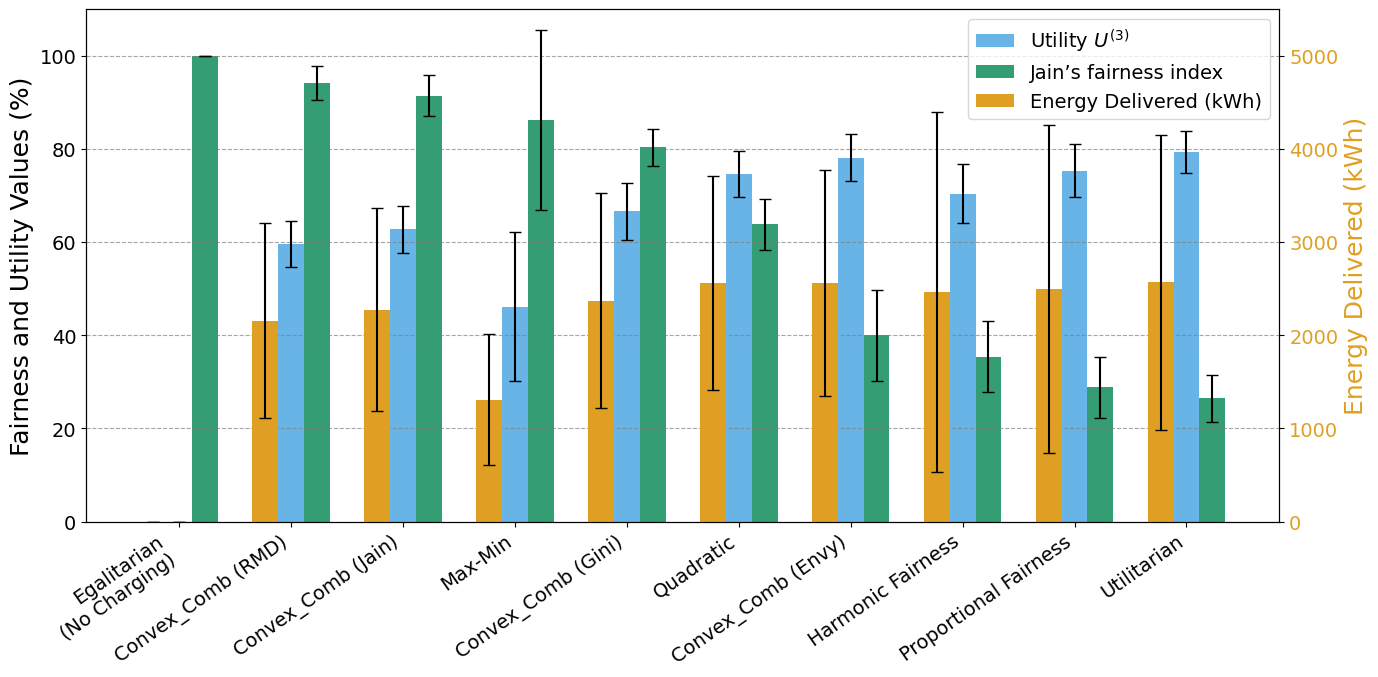

Plotting group 2


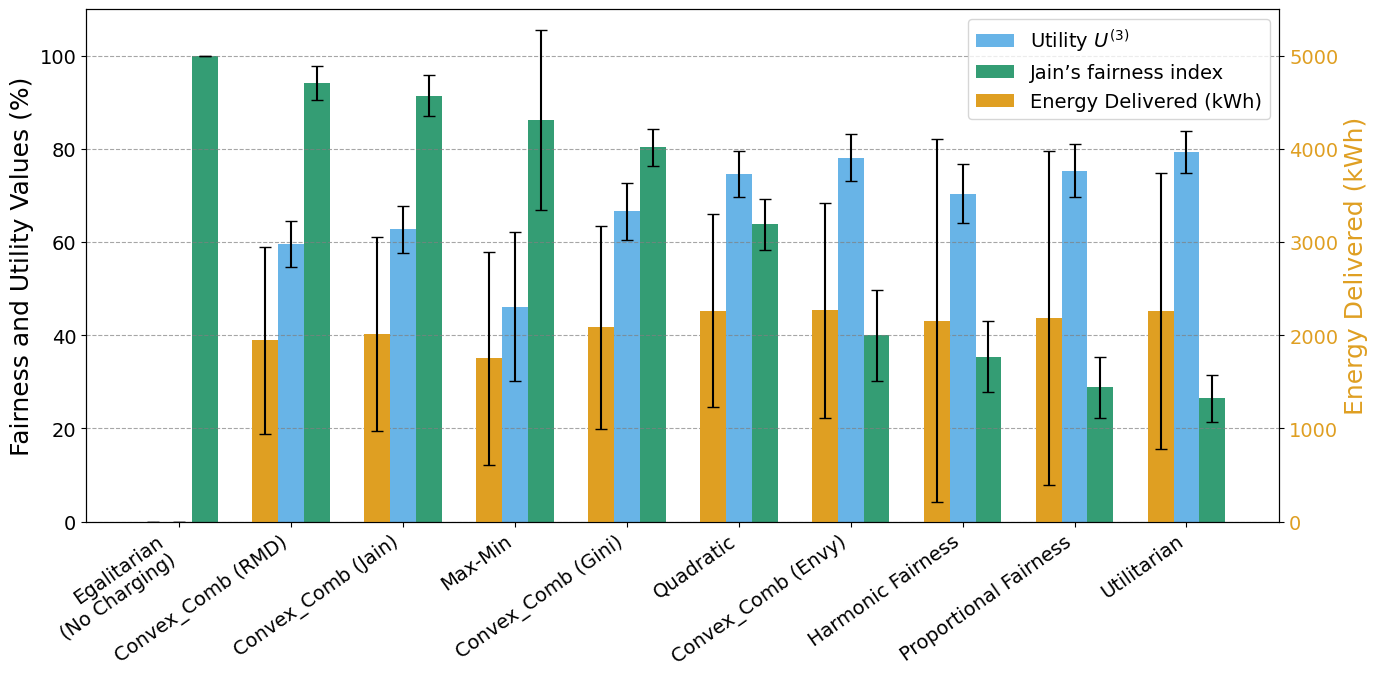

Plotting group 4


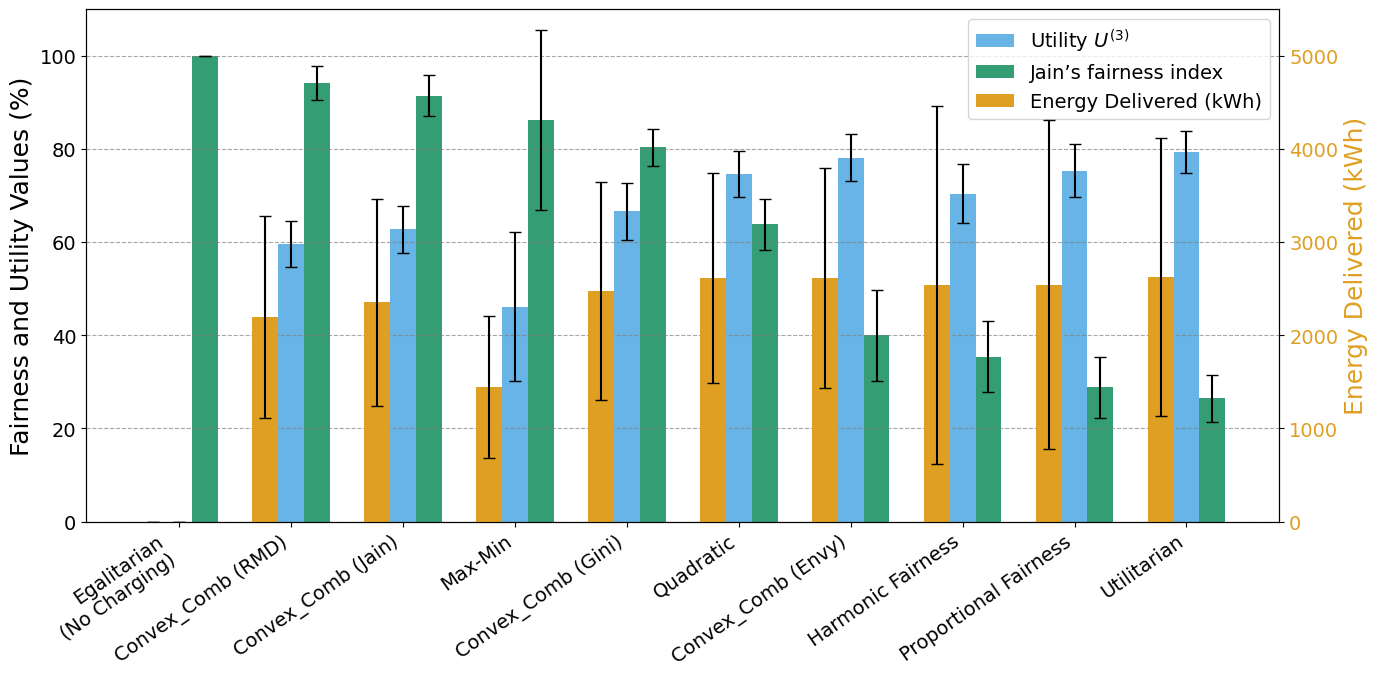

Plotting group 5


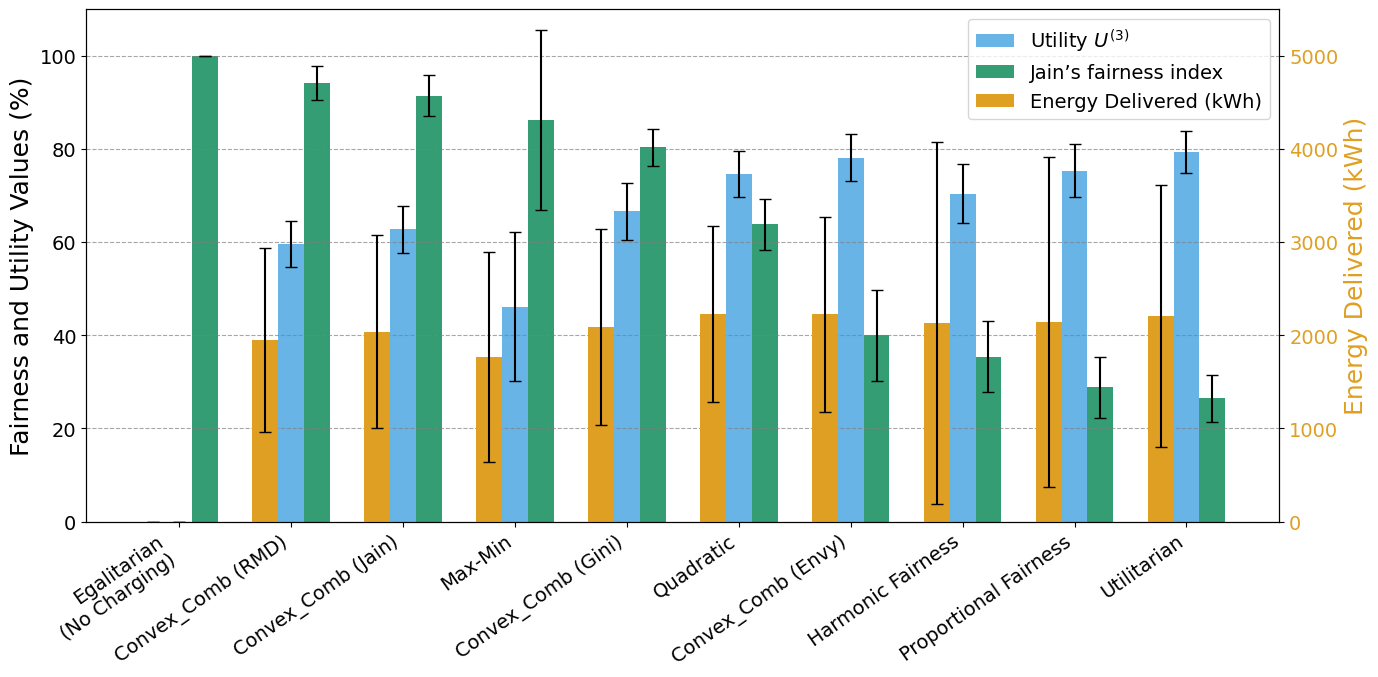

Plotting all groups


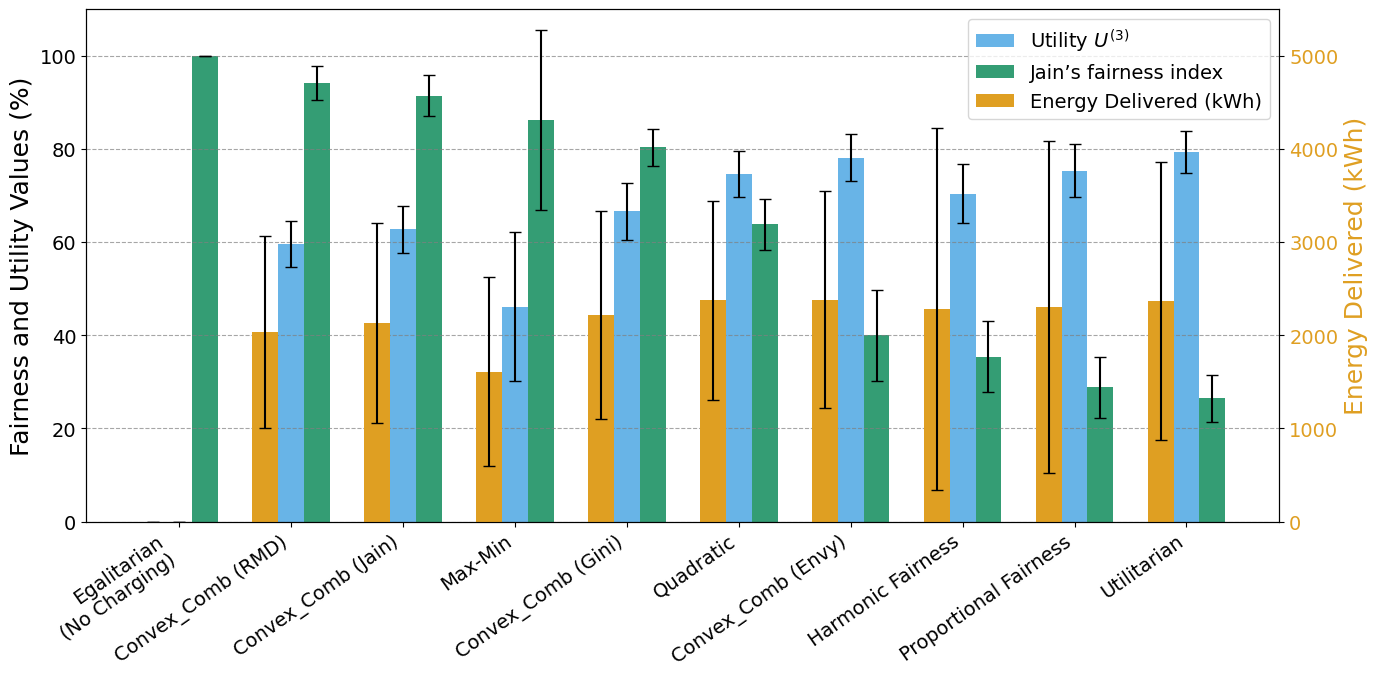

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 14})

def plot_energy_utility_fairness_combined(df_soc, df_metrics, map_objective_index_to_name, group_id=None, verbose=True):
    """
    Left y-axis: Energy Delivered (kWh) with std (green).
    Right y-axis: Utility (U^3) and Jain's fairness index with std (blue, orange).
    Ordering and renaming follow the utility/fairness reference code.
    """

    df_soc = df_soc.copy()
    if group_id is not None:
        df_soc = df_soc[df_soc['group'] == group_id].copy()

    list_cols = ['final_soc_list', 'initial_soc_list', 'desired_soc_list', 'battery_capacity_list']
    for col in list_cols:
        if col not in df_soc.columns:
            print(f"Error: Required column '{col}' not found.")
            return
        df_soc[col] = df_soc[col].apply(
            lambda s: [float(x) for x in str(s).split(',')] if pd.notna(s) else []
        )
    if verbose:
        print(f"Rows before explode: {len(df_soc)}")

    df_long = df_soc.explode(list_cols).copy()
    df_long.rename(columns={
        'final_soc_list': 'final_soc',
        'initial_soc_list': 'initial_soc',
        'desired_soc_list': 'desired_soc',
        'battery_capacity_list': 'battery_capacity_kwh'
    }, inplace=True)

    numeric_cols = ['final_soc', 'initial_soc', 'desired_soc', 'battery_capacity_kwh']
    for col in numeric_cols:
        df_long[col] = pd.to_numeric(df_long[col], errors='coerce')
    df_long.dropna(subset=numeric_cols, inplace=True)

    if verbose:
        print(f"Rows after explode & cleanup: {len(df_long)}")
        print(f"Non-NaN counts -> final_soc: {df_long['final_soc'].notna().sum()}, "
              f"initial_soc: {df_long['initial_soc'].notna().sum()}, "
              f"desired_soc: {df_long['desired_soc'].notna().sum()}, "
              f"battery_capacity_kwh: {df_long['battery_capacity_kwh'].notna().sum()}")

    df_long['energy'] = (df_long['final_soc'] - df_long['initial_soc']) * df_long['battery_capacity_kwh']

    energy_agg = df_long.groupby('Objective_Index', as_index=False).agg(
        energy_mean=('energy', 'mean'),
        energy_std=('energy', 'std'),
        energy_sem=('energy', 'sem')
    )
    if verbose:
        print(f"Rows after energy aggregation (unique objectives): {len(energy_agg)}")
    

    if not set(energy_agg['Objective_Index']).intersection(df_metrics['Objective_Index'].unique()):
        if verbose:
            print("Detected index offset between SOC and metrics files.")
        energy_agg['Objective_Index'] = energy_agg['Objective_Index']

    # ---- METRICS PART (from df_metrics; same logic as your utility/fairness code) ----
    dfm = df_metrics.copy()
    if verbose:
        print(f"Rows before aggregation (metrics): {len(dfm)}")
        util_non_nan = dfm['Metrics_Utility'].notna().sum()
        fair_non_nan = dfm["Metrics_Jain's Fairness Index"].notna().sum()
        print(f"Non-NaN before aggregation -> Utility: {util_non_nan}, Fairness: {fair_non_nan}")

    agg_results = dfm.groupby('Objective_Index', as_index=False).agg({
        "Metrics_Utility": lambda s: 100. - s.mean(skipna=True) * 100,
        "Metrics_Jain's Fairness Index": lambda s: s.mean(skipna=True) * 100,
    })
    std_results = dfm.groupby('Objective_Index', as_index=False).agg({
        "Metrics_Utility": lambda s: s.std(skipna=True) * 100,
        "Metrics_Jain's Fairness Index": lambda s: s.std(skipna=True) * 100,
    }).rename(columns={
        "Metrics_Utility": "Metrics_Utility_Std",
        "Metrics_Jain's Fairness Index": "Metrics_Jain's Fairness Index_Std",
    })
    agg_results = agg_results.merge(std_results, on='Objective_Index', how='left')

    if verbose:
        print(f"Rows after metrics aggregation (unique objectives): {len(agg_results)}")

    # Mapping names (use same convention as the metrics reference)
    if isinstance(map_objective_index_to_name, dict):
        agg_results['Objective'] = agg_results['Objective_Index'].map(map_objective_index_to_name.get)
    else:
        agg_results['Objective'] = agg_results['Objective_Index'].map(lambda x: map_objective_index_to_name[x])

    metrics_plot = agg_results.copy()
    custom_order = [
        'Egalitarian\n(No Charging)', 'Convex_Comb (RMD)', 'Convex_Comb (Jain)',
        'Max-Min', 'Convex_Comb (Gini)', 'Quadratic', 'Convex_Comb (Envy)',
        'Harmonic Fairness', 'Proportional Fairness', 'Utilitarian'
    ]
    final_order = [name for name in custom_order if name in metrics_plot['Objective'].values]
    metrics_plot['Objective'] = pd.Categorical(metrics_plot['Objective'], categories=final_order, ordered=True)
    metrics_plot = metrics_plot.sort_values('Objective').reset_index(drop=True)

    # Join energy on Objective_Index, then apply the same ordering
    merged = metrics_plot.merge(energy_agg, on='Objective_Index', how='left')
    merged = merged.sort_values('Objective').reset_index(drop=True)

    if verbose:
        print(f"Plotted objectives: {list(merged['Objective'])}")

    # ---- Plot: Energy (left axis), Utility and Fairness (right axis) ----
    fig, ax1 = plt.subplots(figsize=(14, 7))
    ax2 = ax1.twinx()

    n = len(merged)
    group_spacing = 1.3
    x = np.arange(n) * group_spacing
    bar_width = 0.30

    # Energy (left axis, green) with std
    bars_energy = ax2.bar(
        x - bar_width, merged['energy_mean'],
        yerr=merged['energy_std'].fillna(0),
        width=bar_width,
        label='Energy Delivered (kWh)',
        color="#df9f22",
        capsize=4
    )

    # Utility (right axis, blue) with std
    bars_utility = ax1.bar(
        x,
        merged["Metrics_Utility"],
        yerr=merged["Metrics_Utility_Std"].fillna(0),
        width=bar_width,
        label=r'Utility $U^{(3)}$',
        color="#68b4e7",
        capsize=4
    )

    # Jain's fairness (right axis, orange) with std
    bars_jain = ax1.bar(
        x + bar_width,
        merged["Metrics_Jain's Fairness Index"],
        yerr=merged["Metrics_Jain's Fairness Index_Std"].fillna(0),
        width=bar_width,
        label="Jain’s fairness index",
        color="#349d74",
        capsize=4
    )

    # Axis labels and ticks (preserve labels/scales from references)
    ax2.set_ylabel("Energy Delivered (kWh)", fontsize=18, color='#df9f22')
    ax1.set_ylabel("Fairness and Utility Values (%)", fontsize=18)
    ax2.tick_params(axis='y', labelcolor='#df9f22', labelsize=14)
    ax2.set_ylim(0, 5500)
    ax1.set_ylim(0, 110)  # percentages like reference
    ax1.tick_params(axis='y', labelsize=14)

    # Align zeros on both y-axes (from energy reference)
    y1_min, y1_max = ax2.get_ylim()
    y2_min, y2_max = ax1.get_ylim()
    ratio1 = abs(y1_min / y1_max) if y1_max != 0 and y1_min < 0 else 0
    ratio2 = abs(y2_min / y2_max) if y2_max != 0 and y2_min < 0 else 0
    max_ratio = max(ratio1, ratio2)
    if max_ratio > 0:
        if y1_max > 0: ax1.set_ylim(bottom=-max_ratio * y1_max)
        if y2_max > 0: ax2.set_ylim(bottom=-max_ratio * y2_max)

    ax1.set_xticks(x)
    ax1.set_xticklabels(merged["Objective"], rotation=35, ha="right", fontsize=14)

    # Legend (combine both axes)
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right", fontsize=14)

    ax1.grid(axis='y', linestyle='--', color='gray', alpha=0.7, zorder=0)
    # plt.title("Energy, Utility, and Fairness across Objective Functions", fontsize=18)
    plt.tight_layout()
    if group_id is None:
        plt.savefig("energy_utility_fairness_combined_all_groups.png", dpi=300, bbox_inches='tight')
    else:
        plt.savefig(f"energy_utility_fairness_g{group_id}.png", dpi=300, bbox_inches='tight')
    plt.show()


df_soc_comb = pd.read_csv('socs_per_instance_h_lns_mip.csv')
# IDs of the groups you want to exclude
groups_to_exclude = {3, 6}
# Filter SOC dataframe
df_soc_filtered = df_soc_comb[~df_soc_comb['group'].isin(groups_to_exclude)].copy()
# Filter metrics dataframe (if you have one)
df_metrics_filtered = df_h_lns_mip[~df_h_lns_mip['Group'].isin(groups_to_exclude)].copy()


for grp in [1, 2, 4, 5]:
    print(f"Plotting group {grp}")
    plot_energy_utility_fairness_combined(
        df_soc=df_soc_filtered,
        df_metrics=df_metrics_filtered,
        map_objective_index_to_name=OBJECTIVE_NAMES,
        group_id=grp,
        verbose=False
    )

# Plot all groups
print("Plotting all groups")
plot_energy_utility_fairness_combined(
    df_soc=df_soc_filtered,
    df_metrics=df_metrics_filtered,
    map_objective_index_to_name=OBJECTIVE_NAMES,
    group_id=None,
    verbose=False
)

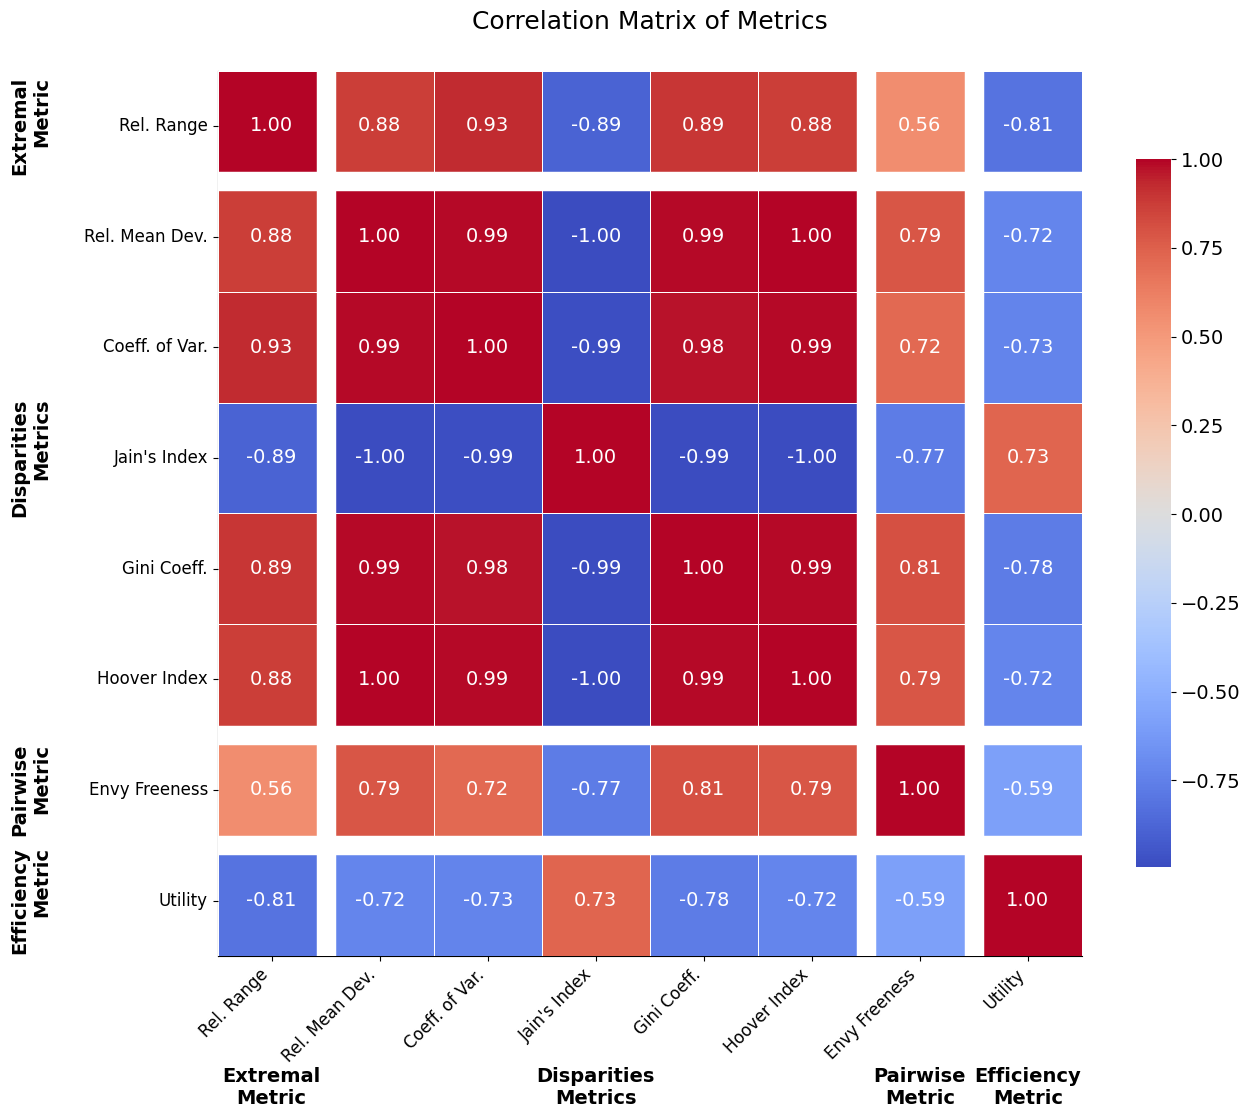

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the datasets
df_mip = pd.read_csv('output_mip.csv')
df_h_lns_mip = pd.read_csv('output_h_lns_mip.csv')
df_h_lns = pd.read_csv('output_h_lns.csv')
df_h = pd.read_csv('output_h.csv')

# Combine the dataframes
combined_df = pd.concat([df_mip, df_h_lns_mip, df_h_lns, df_h], ignore_index=True)

# Define the groups of metrics in the desired order
group1_metrics = ['Metrics_Relative Range']
group2_disparity_metrics = [
    'Metrics_Relative Mean Deviation',      # RMD
    'Metrics_Coefficient of Variation',     # Coeff of Var
    "Metrics_Jain's Fairness Index",        # Jain
    'Metrics_Gini Coefficient',             # Gini
    'Metrics_Hoover Index',                 # Hoover
]
group3_metrics = ['Metrics_Envy Freeness']
group4_metrics = ['Metrics_Utility']

# Create the final ordered list of metrics
ordered_metrics = group1_metrics + group2_disparity_metrics + group3_metrics + group4_metrics

# Select and reorder the metrics columns from the dataframe
metrics_df = combined_df[ordered_metrics]

# Rename columns for a cleaner plot
new_column_names = {
    'Metrics_Envy Freeness': 'Envy Freeness',
    'Metrics_Relative Mean Deviation': 'Rel. Mean Dev.',
    'Metrics_Gini Coefficient': 'Gini Coeff.',
    "Metrics_Jain's Fairness Index": "Jain's Index",
    'Metrics_Relative Range': 'Rel. Range',
    'Metrics_Coefficient of Variation': 'Coeff. of Var.',
    'Metrics_Hoover Index': 'Hoover Index',
    'Metrics_Utility': 'Utility'
}
metrics_df = metrics_df.rename(columns=new_column_names)

# Calculate the correlation matrix
correlation_matrix = metrics_df.corr()

# --- Plotting ---
fig, ax = plt.subplots(figsize=(14, 12))

# Plot the correlation matrix as a heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5,
    annot_kws={"size": 14},
    ax=ax,
    cbar_kws={'shrink': 0.8}  # Make color bar a bit smaller
)

# --- Separators ---
separator_indices = [
    len(group1_metrics),
    len(group1_metrics) + len(group2_disparity_metrics),
    len(group1_metrics) + len(group2_disparity_metrics) + len(group3_metrics)
]

for index in separator_indices:
    ax.axhline(y=index, color='white', linewidth=14)
    ax.axvline(x=index, color='white', linewidth=14)

# --- Group Labels ---
group_boundaries = [0] + separator_indices + [len(ordered_metrics)]
group_centers = [(group_boundaries[i] + group_boundaries[i+1]) / 2 for i in range(len(group_boundaries) - 1)]

group_labels_x = group_labels_y = ["Extremal\nMetric", "Disparities\nMetrics", "Pairwise\nMetric", "Efficiency\nMetric"]

# Create a secondary x-axis for the top labels
secax_x = ax.secondary_xaxis('bottom')
secax_x.set_xticks(group_centers)
secax_x.set_xticklabels(group_labels_x, fontsize=14, fontweight='bold')
secax_x.tick_params(axis='x', length=0, pad=80)  # increased pad for readability

# Create a secondary y-axis for the left labels
secax_y = ax.secondary_yaxis('left')
secax_y.set_yticks(group_centers)
secax_y.set_yticklabels(group_labels_y, fontsize=14, fontweight='bold', rotation=90, va='center')
secax_y.tick_params(axis='y', length=0, pad=120)  # increased pad for readability

# --- Final Customizations ---
ax.set_title('Correlation Matrix of Metrics', fontsize=18, pad=30)
ax.tick_params(axis='x', labelsize=12, labelrotation=45)
ax.tick_params(axis='y', labelsize=12, labelrotation=0)
# Ensure x-tick labels are aligned correctly
for label in ax.get_xticklabels():
    label.set_ha('right')

plt.tight_layout(rect=[0.05, 0, 1, 0.95])  # Adjust layout to prevent labels from being cut off
plt.savefig('correlation_matrix_metrics.png', dpi=300, bbox_inches='tight')
plt.show()